# kaft · Geometry Survey
### Exploring classical and information-geometric metrics via the DivergenceRegistry

This notebook walks through all 9 metrics currently in `kaft.geometry`,
demonstrating what each one measures, how they differ, and why the choice
of metric shapes the geometry of your data space.

In [14]:
# If running locally — adjust path to your repo
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-e",
                "/Users/ashwinpalve/crucible/kaft", "-q"], check=True)


import importlib, sys
mods_to_remove = [key for key in sys.modules if key.startswith("kaft")]
for mod in mods_to_remove:
    del sys.modules[mod]

print(f"Cleared {len(mods_to_remove)} cached kaft modules")

Cleared 17 cached kaft modules


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from kaft.geometry import DivergenceRegistry

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
rng  = np.random.default_rng(SEED)

## 1 · Registry Survey — what's available

In [17]:
r = DivergenceRegistry()
metrics = r.available()
print(f"Total metrics registered: {len(metrics)}\n")
for name in metrics:
    m = r.get(name)
    print(f"  {name:30s}  →  geometry_type: {m.geometry_type()}")

Total metrics registered: 9

  euclidean                       →  geometry_type: euclidean
  gaussian_curved                 →  geometry_type: curved
  minkowski                       →  geometry_type: minkowski
  fisher_rao                      →  geometry_type: fisher_rao
  kl_divergence                   →  geometry_type: kl_divergence
  jensen_shannon                  →  geometry_type: jensen_shannon
  alpha_hellinger                 →  geometry_type: alpha_0.00
  alpha_bhattacharyya             →  geometry_type: alpha_0.50
  alpha_reverse                   →  geometry_type: alpha_-0.50


## 2 · Test Data — two families of distributions

We'll work with 20 random probability-like vectors in 8 dimensions.
All metrics normalise these internally, so raw values are fine.

In [18]:
N, D = 20, 8
vectors = rng.random((N, D))           # raw positive values
# Each metric internally normalises to a probability simplex where needed
print(f"Data shape: {vectors.shape}  (N={N} vectors, D={D} dimensions)")

Data shape: (20, 8)  (N=20 vectors, D=8 dimensions)


## 3 · Classical vs Information Geometry — distance matrices side by side

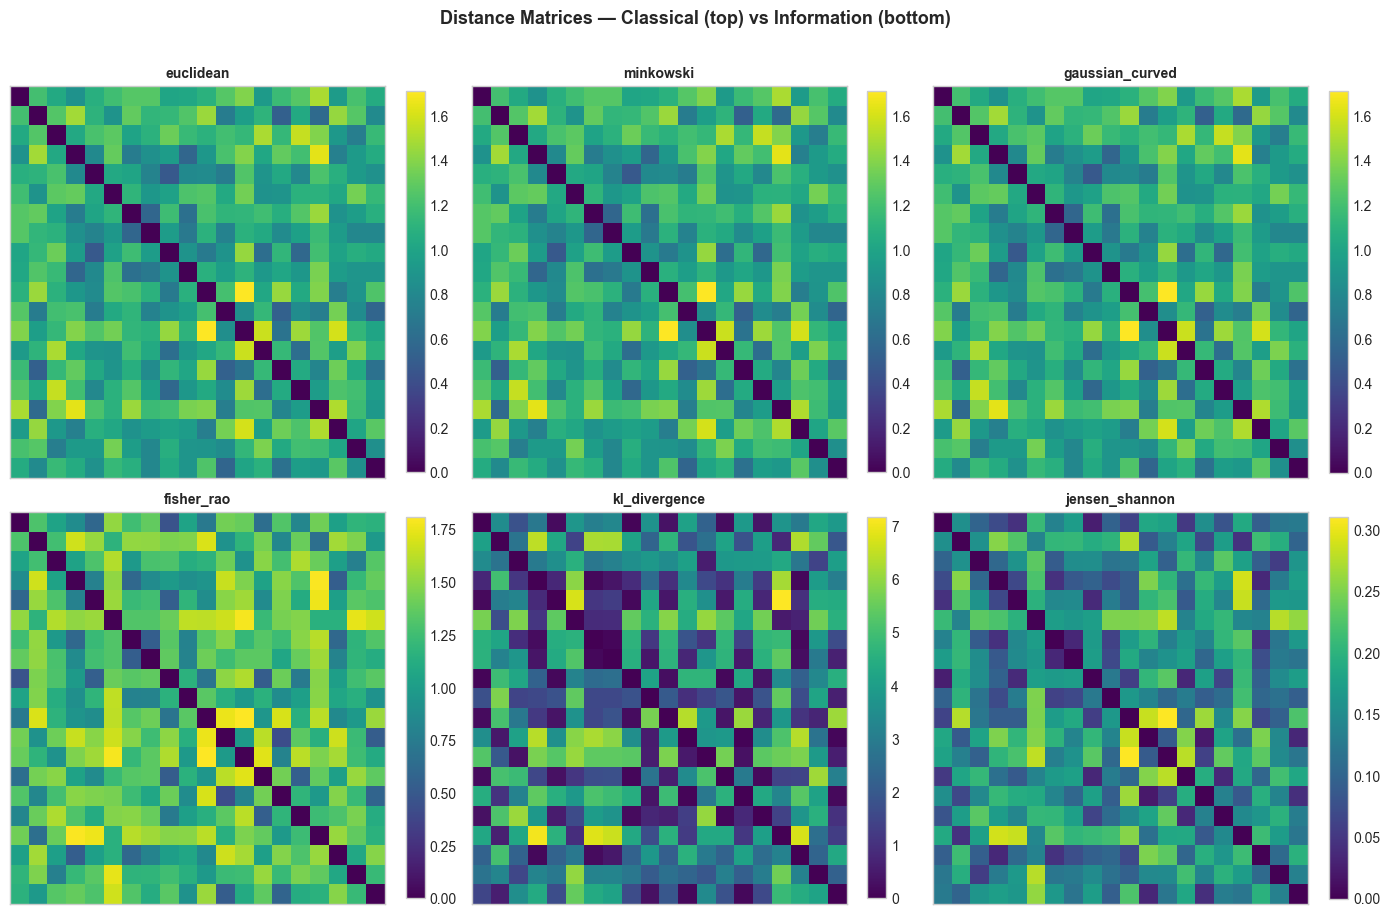

Saved: distance_matrices.png


In [19]:
classical   = ["euclidean", "minkowski", "gaussian_curved"]
information = ["fisher_rao", "kl_divergence", "jensen_shannon"]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Distance Matrices — Classical (top) vs Information (bottom)", 
             fontsize=13, fontweight="bold", y=1.01)

for i, name in enumerate(classical + information):
    ax  = axes[i // 3][i % 3]
    m   = r.get(name)
    D_  = m.distances(vectors)
    im  = ax.imshow(D_, cmap="viridis", aspect="auto")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("distance_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: distance_matrices.png")

## 4 · The Alpha Family — parametric sweep

Alpha-divergence is a 1-parameter family unifying multiple divergences.
- `α = 0.0`  →  Hellinger (symmetric, geometric mean)
- `α = 0.5`  →  Bhattacharyya overlap coefficient  
- `α = -0.5` →  Reverse-KL direction

The `speed_field` visualises how the geometry *deforms space* — 
darker = slower wave propagation = higher curvature in that region.

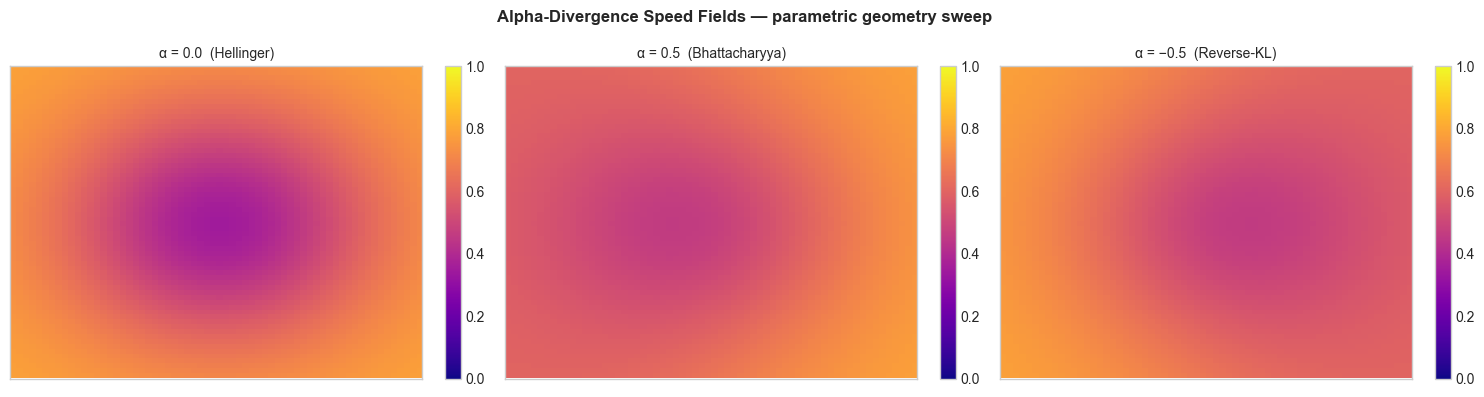

In [20]:
alpha_metrics = ["alpha_hellinger", "alpha_bhattacharyya", "alpha_reverse"]
labels        = ["α = 0.0  (Hellinger)", "α = 0.5  (Bhattacharyya)", "α = −0.5  (Reverse-KL)"]
GRID          = 64

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Alpha-Divergence Speed Fields — parametric geometry sweep", 
             fontsize=12, fontweight="bold")

for ax, name, label in zip(axes, alpha_metrics, labels):
    m     = r.get(name)
    field = m.speed_field(GRID)
    im    = ax.imshow(field, cmap="plasma", vmin=0, vmax=1, aspect="auto")
    ax.set_title(label, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("alpha_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · KL vs JS - the asymmetry proof

KL divergence is *not* symmetric: KL(p‖q) ≠ KL(q‖p).  
Jensen-Shannon *is* symmetric by construction: JS(p‖q) = JS(q‖p).

We verify this numerically below.

KL  max|D - Dᵀ| = 5.1547  ← asymmetric ✗
JS  max|D - Dᵀ| = 0.00e+00  ← symmetric  ✓


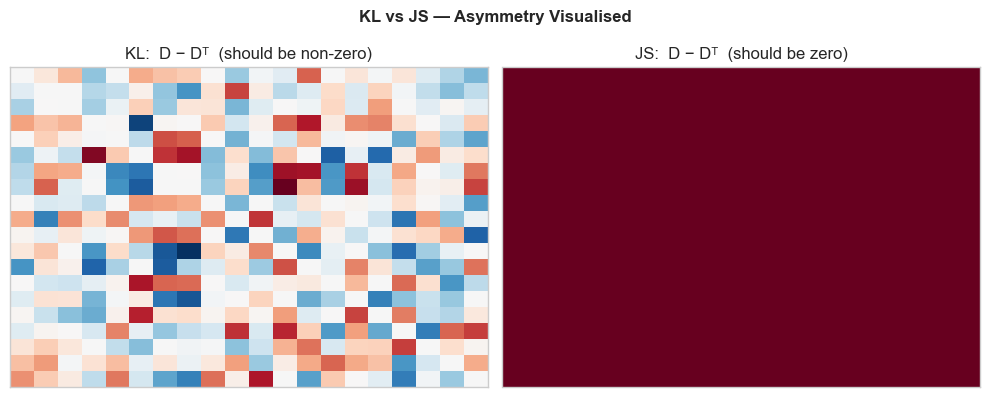

In [21]:
kl = r.get("kl_divergence")
js = r.get("jensen_shannon")

D_kl = kl.distances(vectors)
D_js = js.distances(vectors)

kl_asymmetry = np.max(np.abs(D_kl - D_kl.T))
js_asymmetry = np.max(np.abs(D_js - D_js.T))

print(f"KL  max|D - Dᵀ| = {kl_asymmetry:.4f}  ← asymmetric ✗")
print(f"JS  max|D - Dᵀ| = {js_asymmetry:.2e}  ← symmetric  ✓")

# Plot the difference
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("KL vs JS — Asymmetry Visualised", fontsize=12, fontweight="bold")

ax1.imshow(D_kl - D_kl.T, cmap="RdBu", aspect="auto")
ax1.set_title("KL:  D − Dᵀ  (should be non-zero)")
ax1.set_xticks([]); ax1.set_yticks([])

ax2.imshow(D_js - D_js.T, cmap="RdBu", aspect="auto")
ax2.set_title("JS:  D − Dᵀ  (should be zero)")
ax2.set_xticks([]); ax2.set_yticks([])

plt.tight_layout()
plt.savefig("kl_vs_js_asymmetry.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 ·  Alpha-divergence sweep  

In [22]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots()
alphas = np.linspace(-0.95, 0.95, 60)  # 60 frames

def update(frame):
    ax.clear()
    from kaft.geometry.information import AlphaDivergence
    m = AlphaDivergence(alpha=alphas[frame])
    field = m.speed_field(64)
    ax.imshow(field, cmap="plasma", vmin=0, vmax=1)
    ax.set_title(f"α = {alphas[frame]:.2f}")
    ax.set_xticks([]); ax.set_yticks([])

anim = FuncAnimation(fig, update, frames=60, interval=80)
anim.save("alpha_sweep.gif", writer=PillowWriter(fps=15))
plt.close()


What you've seen:
- **9 metrics** across classical and information geometry
- **Distance matrices** — how each metric carves up the same data differently  
- **Alpha-divergence sweep** — one parameter, three geometries
- **KL vs JS** — asymmetry proven numerically

### Next: `02_wave_propagation.ipynb`

The `speed_field` of each metric defines a **variable-speed medium**.  
A wave front propagating through it reveals the geometry viscerally —  
faster where space is flat, slower where it's curved.
